# Field inference of a single (realistic) source with the Fast Multipole Method

This notebook calcuates the potential of a single source via the Fast Multipole Method in 2D (https://github.com/flatironinstitute/fmm2d) and serves as a benchmark for our novel method.

Check for 2D magnetic field of a magnetized prism.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings

from hypermagnetics import plots
from hypermagnetics.sources import configure, read_db
from hypermagnetics.fmm_sources import potential2D, potential2D_loop, field2d_grid
from hypermagnetics.mt_eval import field_mt


warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

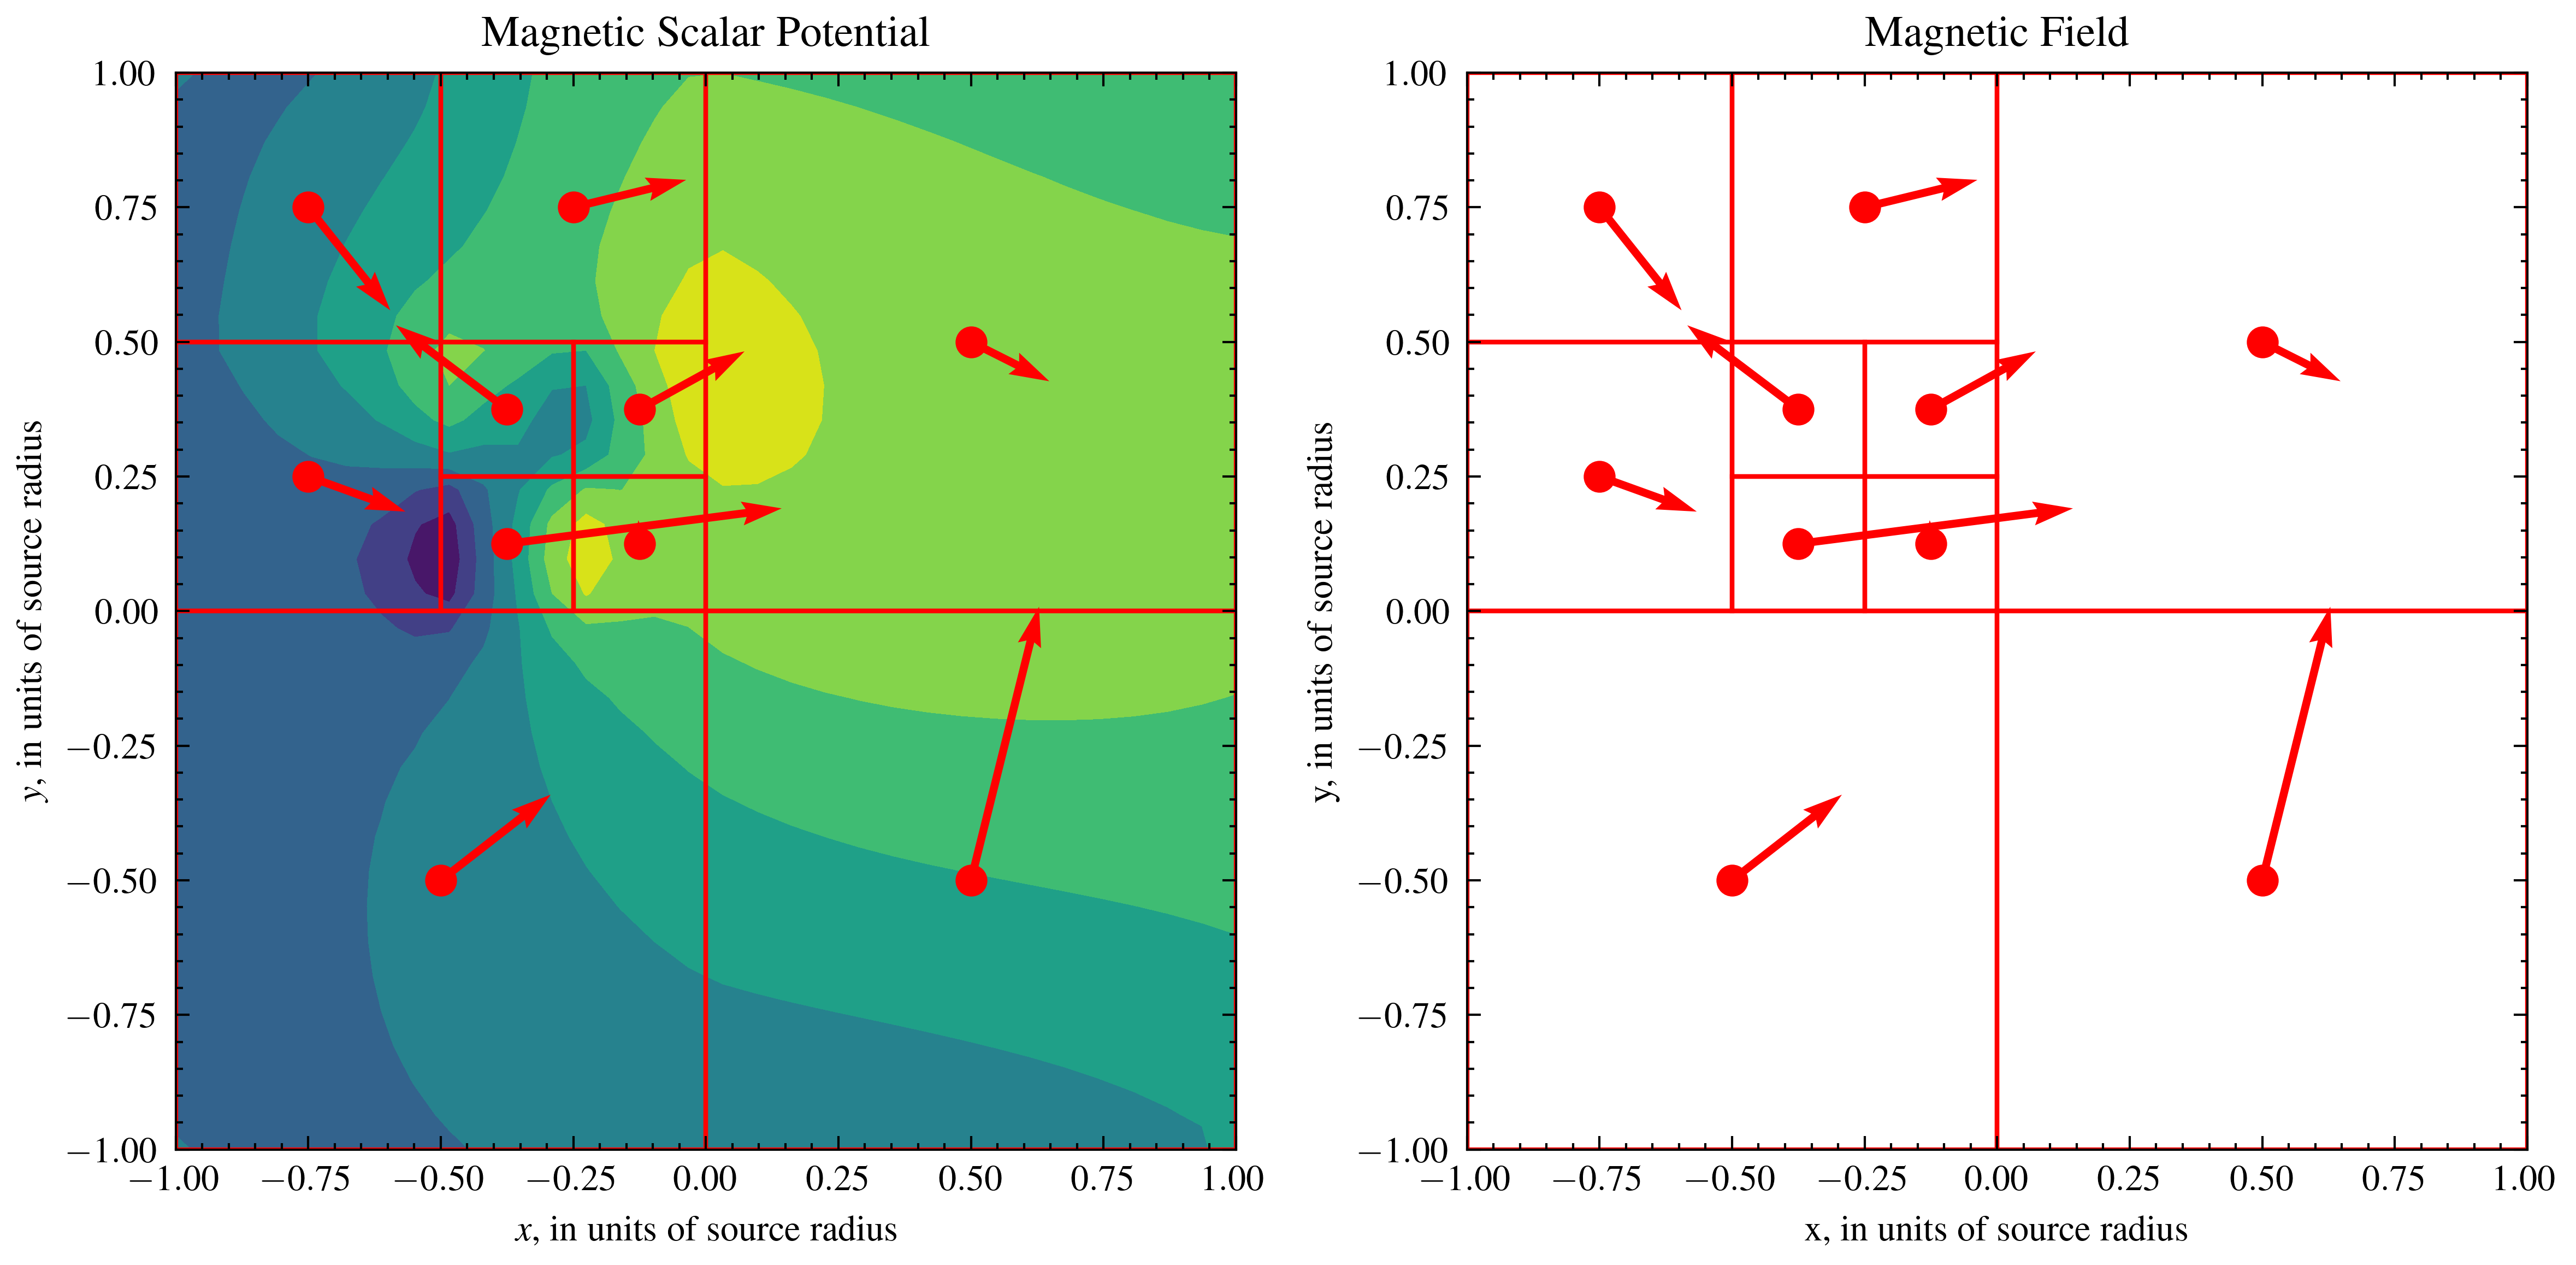

In [2]:
source_cfg = {
    "shape": "prism",
    "n_samples": 1,
    "n_sources": 12,
    "lim": 1,
    "res": 32,
    "dim": 2,
    "min_size": 0.5,
    "max_size": 1,
    "target_source": True,
    "line": False,
    "quadtree": True,
    "eps": 0,
    "seed": 0,
}
# train = configure(**source_cfg)
db_name = "eval_qt_exact_42"
train = read_db(f"{db_name}_{5}_{10}.h5", read_grid=True)
plots(train, loc=True, edge=True)

## Code from FMM2D
https://github.com/flatironinstitute/fmm2d/blob/main/src/laplace/rfmm2d.f#L144
- 2D dipole vector is represented in complex form `dx + i*dy`
- Can then be more easily treated as directional derivatives of monopole (source) potentials
- negative sign in `ztmp` is conventional; **TODO** Check how FMM is using this in Green's function

```
do i = 1,ns
    do j = 1,nd
        ztmp = -(dipvec(j,1,i)+eye*dipvec(j,2,i))
        dipstr1(j,i) = dipstr(j,i)*ztmp
    enddo
enddo
```


## Directly from FMM2D

## Equivalent for MagTense
2D magnetiziation in $xy$-plane and prism is elongated in $z$-direction.

Convert magnetic moment to magnetization: $M = m / (2 * a * 2 * b)$

In [5]:
for eps in [0, 1e-3, 1e-5, 1e-7, 1e-9]:
    # print("Source 1 on all other locations")
    # source = train['sources'][0:1, 0:1]
    # loc = train['r'][0][1:]
    # mt_sim, _ = field_mt(source, loc + eps, train['shape'])
    # # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    # _, fmm_field = potential2D(source, train['shape'], loc + eps)
    # # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    # rel_err = np.abs((mt_sim[..., :2] - fmm_field) / mt_sim[..., :2]) * 100
    # print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")

    # print("Other sources on source 1")
    # source = train['sources'][0:1, 1:]
    # loc = train['r'][0][0:1]
    # mt_sim, _ = field_mt(source, loc + eps, train['shape'])
    # # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    # _, fmm_field = potential2D(source, train['shape'], loc + eps)
    # # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    # rel_err = np.abs((mt_sim[..., :2] - fmm_field) / mt_sim[..., :2]) * 100
    # print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")

    # print("Source 1 on all locations")
    source = train['sources'][0:1, 0:1]
    loc = train['r'][0]
    mt_sim, _ = field_mt(source, loc + eps, train['shape'])
    # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    _, fmm_field = potential2D(source, train['shape'], loc + eps)
    # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    rel_err = np.abs((mt_sim[..., :2] - fmm_field) / mt_sim[..., :2]) * 100
    print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")
    print(fmm_field[0, 0, :2])
    print(mt_sim[0, 0, :2])
    print("\n")

Eps: 0.0e+00, Mean Error: 23.66 [%], Median Error: 5.04 [%]
[-0.51806653 -0.39761218]
[-0.51724407 -0.39698098]


Eps: 1.0e-03, Mean Error: 23.69 [%], Median Error: 4.95 [%]
[-0.51432499 -0.39484847]
[-0.51724306 -0.39697966]


Eps: 1.0e-05, Mean Error: 1079.85 [%], Median Error: 7.10 [%]
[-30.38685358  60.53736222]
[-0.51724407 -0.39698098]


Eps: 1.0e-07, Mean Error: 4691636.72 [%], Median Error: 7.10 [%]
[-456594.58300781  -22064.078125  ]
[-0.51724407 -0.39698098]


Eps: 1.0e-09, Mean Error: 23.66 [%], Median Error: 5.04 [%]
[-0.51806653 -0.39761218]
[-0.51724407 -0.39698098]


